<a href="https://colab.research.google.com/github/JasonL888/AI_Experiments/blob/main/ExplainableAI/hands_on_part_B_Saliency_Grad-CAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hands-On Part B - Saliency and Grad-CAM
This notebook covers the interpretation of a pre-trained CNN image classifier (VGG16) by generating and comparing Saliency Maps and Grad-CAM visualizations.

## 1. Setup and Imports
Import required libraries, including TensorFlow/Keras applications for the pre-trained model.

In [1]:
!pip install opencv-python
!pip install tf-keras-vis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 8.4 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 2.0.0
    Uninstalling wrapt-2.0.0:
      Successfully uninstalled wrapt-2.0.0


In [2]:
# Standard imports
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image
import cv2 # Used only for visualization utility
import requests
from io import BytesIO

# Keras Applications imports
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.imagenet_utils import decode_predictions

from tf_keras_vis.saliency import Saliency
from tf_keras_vis.gradcam import Gradcam
from tf_keras_vis.utils.scores import CategoricalScore
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear

# Set seed for reproducibility (optional)
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2.Load Model and Data (VGG16 on ImageNet)
Load the VGG16 model and preprocess a sample image.

In [3]:
## --- Configuration --- ##
TARGET_SIZE = (224, 224)
TEST_IMAGE_PATH = 'https://jasonl888.github.io/AI_Experiments/ExplainableAI/labrador.jpg'

# The name of the last convolutional layer in VGG16
LAST_CONV_LAYER_NAME = 'block5_conv3'

In [4]:
## --- Load Model --- ##
# Load VGG16 pre-trained on ImageNet (1000 classes)
model = VGG16(weights='imagenet')
print("VGG16 Model loaded successfully with ImageNet weights.")
model.summary() # Uncomment to see the layer names

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step
VGG16 Model loaded successfully with ImageNet weights.


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# --- Updated Image Preprocessing Function for VGG16 ---
def preprocess_image(img_path_or_url, target_size):
    """
    Loads an image from a local path or a public URL, resizes it,
    and preprocesses it for the VGG16 model.
    """

    # 1. Load the raw image (PIL.Image object)
    if img_path_or_url.lower().startswith('http'):
        # Handle URL
        try:
            print(f"Downloading image from URL: {img_path_or_url}")
            response = requests.get(img_path_or_url)
            response.raise_for_status() # Raise an exception for bad status codes (4xx or 5xx)
            img = Image.open(BytesIO(response.content))
        except requests.exceptions.RequestException as e:
            raise FileNotFoundError(f"Failed to download image from URL: {e}")
    else:
        # Handle Local File Path
        # We must use PIL.Image directly here since keras.preprocessing.image.load_img
        # does not return a modifiable PIL object needed later.
        img = Image.open(img_path_or_url)

    # 2. Resize and Convert to Keras Tensor (same as before)

    # Resize the image to the target size
    img = img.resize(target_size)

    # Convert to numpy array and add a batch dimension (1, 224, 224, 3)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    # Apply VGG16's specific preprocessing (converts RGB to BGR and zero-centers channels)
    img_tensor = preprocess_input(img_array)

    # Return the preprocessed tensor (for the model) and the PIL image (for visualization)
    return img_tensor, img

In [6]:
# Load the test image
try:
    test_img_tensor, original_img = preprocess_image(TEST_IMAGE_PATH, TARGET_SIZE)

    # Make a prediction
    predictions = model.predict(test_img_tensor)
    predicted_class_idx = np.argmax(predictions[0])

    # Decode and display the prediction
    decoded_predictions = decode_predictions(predictions, top=1)[0][0]
    predicted_class_name = decoded_predictions[1]

    print(f"\nTest image loaded. Shape: {test_img_tensor.shape}")
    print(f"Prediction: {predicted_class_name} (Index: {predicted_class_idx})")

except FileNotFoundError:
    print(f"\nERROR: Please ensure the image file '{TEST_IMAGE_PATH}' is in the current directory.")
    predicted_class_idx = None # Stop further execution if file not found

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 868ms/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Test image loaded. Shape: (1, 224, 224, 3)
Prediction: Labrador_retriever (Index: 208)


## 3. Simple Gradient Saliency Map
We use the built-in Saliency class. We also define a score function to tell the library which class prediction to optimize for (in our case, the predicted class).

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(1, 224, 224, 3))']
  warnings.warn(msg)


1-Saliency map generated. Shape: (1, 224, 224)
2-Saliency map generated. Shape: (224, 224)
3-Saliency map generated. Shape: (224, 224)


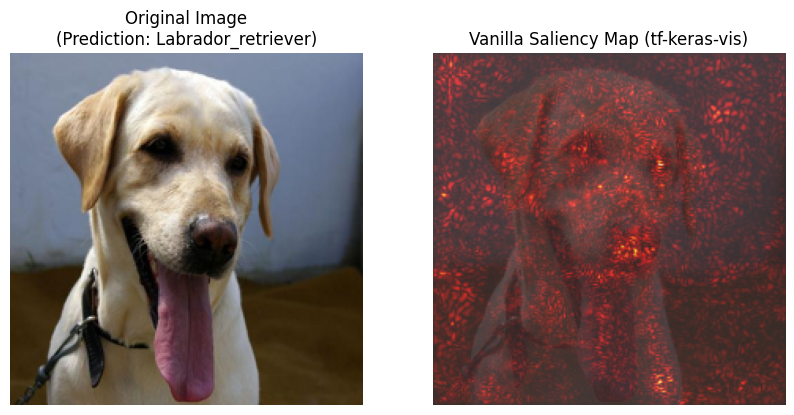

In [7]:
if predicted_class_idx is not None:
    # 1. Define the score function (the class to maximize/get gradient for)
    score = CategoricalScore([predicted_class_idx])

    # 2. Create the Saliency object
    # The 'clone=True' ensures the model is safely copied for gradient computation
    saliency = Saliency(model, model_modifier=None, clone=True)

    # 3. Generate the saliency map
    # The result has shape (1, 224, 224, 3). We only need the first batch item and max over channels.
    saliency_map_vanilla = saliency(score, test_img_tensor)
    print(f"1-Saliency map generated. Shape: {saliency_map_vanilla.shape}")

    # Process for visualization: take max across color channels and normalize
    #saliency_map_vanilla = saliency_map_vanilla[0].max(axis=-1)
    saliency_map_vanilla = np.squeeze(saliency_map_vanilla)
    print(f"2-Saliency map generated. Shape: {saliency_map_vanilla.shape}")
    saliency_map_vanilla = saliency_map_vanilla / saliency_map_vanilla.max()
    print(f"3-Saliency map generated. Shape: {saliency_map_vanilla.shape}")

    # --- Display Function (Re-used/Modified from original) ---
    def display_saliency(original_img, saliency_map, title):
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))

        axes[0].imshow(original_img)
        axes[0].set_title(f"Original Image\n(Prediction: {predicted_class_name})")
        axes[0].axis('off')

        axes[1].imshow(original_img, alpha=0.5)
        # Overlay the saliency map
        axes[1].imshow(saliency_map, cmap='hot', alpha=0.7, interpolation='bilinear')
        axes[1].set_title(title)
        axes[1].axis('off')

        plt.show()

    # Display the result
    display_saliency(original_img, saliency_map_vanilla, "Vanilla Saliency Map (tf-keras-vis)")

## 4. Grad-CAM (Gradient-weighted Class Activation Mapping)
Grad-CAM uses the gradient of the final prediction with respect to the last convolutional layer's features to generate a coarse localization map.

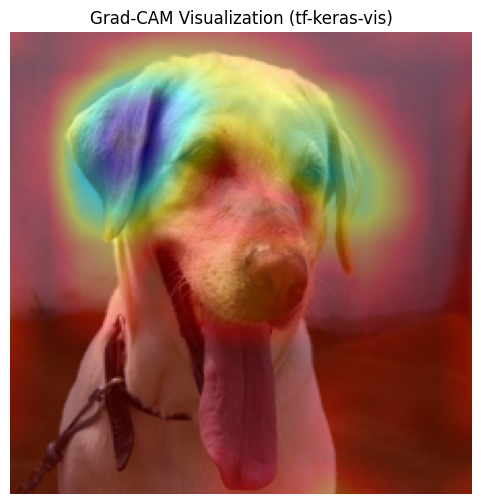

In [8]:
if predicted_class_idx is not None:
    # 1. Define the score function (the class to maximize)
    # The 'score' from the Saliency section is reusable.

    # 2. Create the Gradcam object
    # We use ReplaceToLinear to set the final activation to linear (better for gradients)
    gradcam = Gradcam(model, model_modifier=ReplaceToLinear(), clone=True)

    # 3. Generate the Grad-CAM heatmap
    # `penultimate_layer=-1` finds the last conv layer automatically
    heatmap_gradcam = gradcam(score, test_img_tensor, penultimate_layer=-1)

    # The result has shape (1, 14, 14). We remove the batch dimension.
    heatmap_gradcam = heatmap_gradcam[0]

    # --- Display Function (Re-used/Modified from original) ---
    def display_gradcam(img, heatmap, alpha=0.4):
        # Rescale heatmap to full size (224x224)
        heatmap = np.uint8(255 * heatmap)
        # Resize to VGG16 input size (224, 224)
        heatmap = cv2.resize(heatmap, TARGET_SIZE)
        heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

        img_array_255 = np.array(img).astype('float32')

        # Blend the heatmap and the image (Note: cv2 uses BGR internally)
        superimposed_img = heatmap * alpha + img_array_255 * (1 - alpha)

        # Normalize and display
        superimposed_img = np.clip(superimposed_img, 0, 255).astype('uint8')
        final_img = Image.fromarray(superimposed_img)

        plt.figure(figsize=(6, 6))
        plt.imshow(final_img)
        plt.title("Grad-CAM Visualization (tf-keras-vis)")
        plt.axis('off')
        plt.show()

    # Visualize the Grad-CAM map
    display_gradcam(original_img, heatmap_gradcam)

## 5. Comparison and Discussion

Comparison: Grad-CAM vs. Simple Gradient
Feature|Simple Gradient (Vanilla Saliency)|Grad-CAM (block5_conv3)
-------|----------------------------------|--------
Localization|Pixel-level (Very precise, often noisy)|Region-level (Coarse, highlights object)
Clarity|Highlights high-frequency data (e.g., edges, textures).|Provides a smooth, clear heatmap over the object.
Interpretability|Good for finding minute details the model relies on (often texture/noise).|Excellent for determining where the model is looking (the object itself).

Discussion of Findings:
1. Vanilla Saliency: For the Labrador image, the saliency map will likely show high activation along the sharp outlines of the dog, around the eyes, or on textured areas like fur. This confirms the model uses fine texture and edge features for classification.
2. Grad-CAM: The Grad-CAM heatmap should show a strong, continuous heat spot covering the dog's head and body. This demonstrates that the high-level features learned in the final convolutional block (block5_conv3) successfully localize the object responsible for the final 'Labrador' classification.

What Features Did the Model Actually Learn?
Based on VGG16's successful classification and visualization:
- Low-Level Features (Vanilla Saliency): The initial layers (and thus the Vanilla Saliency) learned to extract fundamental features like edges, corners, and color gradients (e.g., the boundary between the dog and the background).
- High-Level Features (Grad-CAM): The final convolutional block learned to aggregate these low-level features into recognizable semantic parts (e.g., the shape of the dog's head, the texture of its coat). The model is classifying the image based on the spatial presence of the entire "dog" object, not just peripheral details.